#### Naive Bayes Scratch 

### Teorema de Bayes y su aplicación en **Naive Bayes**

El **Teorema de Bayes** permite actualizar la probabilidad de una hipótesis cuando aparece nueva evidencia.

$$
P(A\mid B)=\frac{P(B\mid A)\,P(A)}{P(B)}
$$

Donde:

- $P(A\mid B)$: **posterior** (probabilidad de $A$ después de observar $B$).
- $P(B\mid A)$: **likelihood** o verosimilitud (qué tan probable es $B$ si $A$ es cierto).
- $P(A)$: **prior** (creencia inicial sobre $A$).
- $P(B)$: **evidence** (normalización global).

---

### Aplicación directa a clasificación

En Naive Bayes, se busca la clase $C_k$ más probable para un vector de características $\mathbf{x}=(x_1,\dots,x_n)$:

$$
P(C_k\mid \mathbf{x})=\frac{P(\mathbf{x}\mid C_k)\,P(C_k)}{P(\mathbf{x})}
$$

Para clasificar, $P(\mathbf{x})$ es igual para todas las clases, así que:

$$
\hat{y}=\arg\max_k P(\mathbf{x}\mid C_k)\,P(C_k)
$$

Esto ya simplifica el cálculo: solo se compara una puntuación por clase.

---

### Supuesto *naive* (independencia condicional)

Naive Bayes asume que las variables $x_i$ son condicionalmente independientes dada la clase:

$$
P(\mathbf{x}\mid C_k)=\prod_{i=1}^{n} P(x_i\mid C_k)
$$

Entonces:

$$
\hat{y}=\arg\max_k P(C_k)\prod_{i=1}^{n}P(x_i\mid C_k)
$$

Y, para estabilidad numérica:

$$
\hat{y}=\arg\max_k \left[\log P(C_k)+\sum_{i=1}^{n}\log P(x_i\mid C_k)\right]
$$

---

### ¿Cómo facilita el cálculo este enfoque?

1. **Reduce drásticamente parámetros**  
   Sin el supuesto naive, habría que estimar la distribución conjunta completa $P(x_1,\dots,x_n\mid C_k)$, que crece exponencialmente con $n$.  
   Con Naive Bayes, solo se estiman distribuciones univariadas $P(x_i\mid C_k)$.

2. **Entrenamiento rápido**  
   Basta contar frecuencias (discreto) o estimar media/varianza (gaussiano).

3. **Predicción eficiente**  
   Solo se multiplican/suman (en log) términos por característica y clase.

4. **Funciona bien con pocos datos**  
   Al tener menos parámetros, necesita menos muestras para generalizar.

---

### Estimación de probabilidades en la práctica

- **Prior de clase**:
$$
P(C_k)=\frac{N_k}{N}
$$
- **Likelihood (categórico) con suavizado de Laplace**:
$$
P(x_i=v\mid C_k)=\frac{N_{k,i,v}+\alpha}{N_k+\alpha V_i}
$$
Esto evita probabilidades cero.

---

### Variante según tipo de dato

- **Multinomial Naive Bayes**: conteos (texto, bolsa de palabras).
- **Bernoulli Naive Bayes**: presencia/ausencia de rasgos.
- **Gaussian Naive Bayes**: variables continuas, modeladas con normal.

---

### Resumen conceptual

Bayes aporta la regla para pasar de evidencia a probabilidad de clase.  
Naive Bayes añade una hipótesis fuerte de independencia que vuelve el problema **tractable, rápido y escalable**, manteniendo buen desempeño en muchos casos reales.

In [1]:
import numpy as np
import pandas as  pd
from sklearn.model_selection import train_test_split


In [2]:
data  = pd.read_csv("data.csv")

x = data.drop(columns=['id','diagnosis'])
y = data['diagnosis']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)



In [3]:
class Naive_Bayes:
    def fit(self, x_train, y_train):
        self.classes = np.unique(y_train)
        self.priors = [len(y_train[y_train==c])/len(y_train) for c in self.classes]

        self.means = [x_train[y_train==c].mean() for c in self.classes]
        self.stds = [x_train[y_train==c].std() for c in self.classes]


    def compute_likelihood(self, row, class_idx) :
        likelihood = 1
        for feature in row.index:
            mean = self.means[class_idx][feature]
            std = self.stds[class_idx][feature]
            likelihood *= (1 / (np.sqrt(2 * np.pi) * std)) * np.exp((-(row[feature] - mean)**2) / (2 * std**2))
        return likelihood

    def predict(self, X):
        y_pred = []
        for _, row in X.iterrows():
            posteriors = []
            for i in range(len(self.classes)):
                likelihood = self.compute_likelihood(row, i)
                posteriors.append(likelihood * self.priors[i])
            y_pred.append(self.classes[np.argmax(posteriors)])  
        return np.array(y_pred)     

In [4]:
nb = Naive_Bayes()
nb.fit(x_train, y_train)
predictions = nb.predict(x_test)

accuracy = np.mean(predictions == y_test) * 100
print(f"Accuracy: {accuracy:.2f}%")



Accuracy: 62.28%


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

Text(627.9949494949494, 0.5, 'Real')

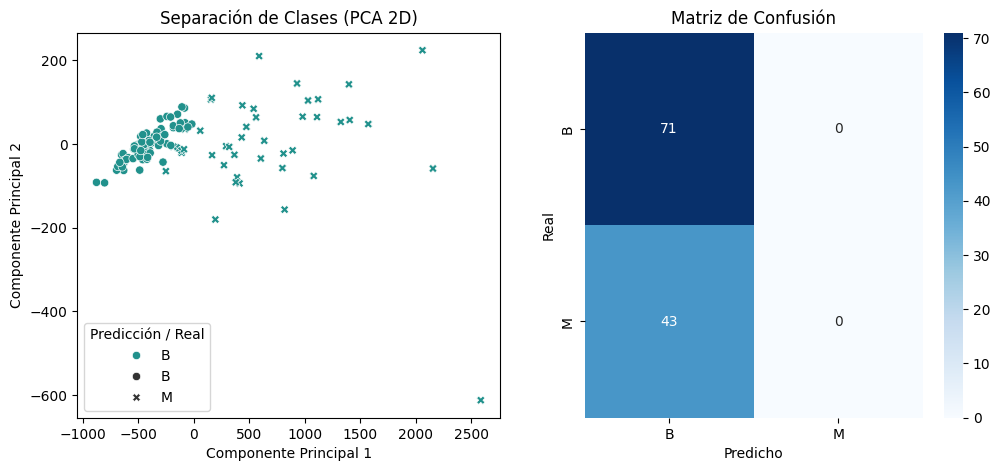

In [17]:
# 1. Reducción de dimensionalidad con PCA para graficar en 2D
from sklearn.impute import SimpleImputer

# Elimina columnas completamente vacías para evitar warnings de imputación
x_test_clean = x_test.dropna(axis=1, how="all")

imputer = SimpleImputer(strategy="median")
x_test_imputed = imputer.fit_transform(x_test_clean)

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(x_test_imputed)

plt.figure(figsize=(12, 5))

# Gráfica de Dispersión (Scatter Plot)
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=predictions, palette='viridis', style=y_test)
plt.title("Separación de Clases (PCA 2D)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Predicción / Real")

# 2. Matriz de Confusión para ver dónde falló el modelo
cm = confusion_matrix(y_test, predictions)
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nb.classes, yticklabels=nb.classes)
plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [16]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

## Versión robusta (mejorada)

Esta sección aplica mejoras para que el modelo sea más estable y evaluable:

- Split estratificado para mantener proporciones de clase en entrenamiento y prueba.
- Cálculo en log-probabilidades para reducir underflow numérico.
- Protección con epsilon cuando la desviación estándar es cero o NaN.
- Evaluación más completa: accuracy, precision, recall, F1 y matriz de confusión.

In [5]:
from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    )

In [6]:
candidate_paths = [
    Path("data.csv"),
    Path("Naive_Bayes/Scratch/data.csv"),
    Path("../Scratch/data.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("No se encontro data.csv en las rutas esperadas.")

data_rb = pd.read_csv(data_path)
x_rb = data_rb.drop(columns=["id", "diagnosis"])
y_rb = data_rb["diagnosis"]

x_train_rb, x_test_rb, y_train_rb, y_test_rb = train_test_split(
    x_rb,
    y_rb,
    test_size=0.2,
    random_state=42,
    stratify=y_rb,
    )

print(f"Archivo cargado: {data_path}")
print(f"Train: {x_train_rb.shape} | Test: {x_test_rb.shape}")

Archivo cargado: data.csv
Train: (455, 31) | Test: (114, 31)


In [7]:
class RobustGaussianNaiveBayes:
    def __init__(self, epsilon=1e-9):
        self.epsilon = epsilon

    def fit(self, x_train, y_train):
        self.classes_ = np.unique(y_train)
        self.log_priors_ = {}
        self.means_ = {}
        self.stds_ = {}

        for class_label in self.classes_:
            x_class = x_train[y_train == class_label]
            self.log_priors_[class_label] = np.log(len(x_class) / len(y_train))
            self.means_[class_label] = x_class.mean()
            self.stds_[class_label] = x_class.std().replace(0, self.epsilon).fillna(self.epsilon)

        return self

    def _log_gaussian_likelihood(self, row, class_label):
        mean = self.means_[class_label]
        std = self.stds_[class_label]
        z = (row - mean) / std
        log_terms = -0.5 * np.log(2 * np.pi) - np.log(std) - 0.5 * (z ** 2)
        return np.sum(log_terms)

    def predict(self, x_input):
        predictions = []
        for _, row in x_input.iterrows():
            class_scores = {
                class_label: self.log_priors_[class_label] + self._log_gaussian_likelihood(row, class_label)
                for class_label in self.classes_
            }
            predictions.append(max(class_scores, key=class_scores.get))

        return np.array(predictions)

In [8]:
robust_nb = RobustGaussianNaiveBayes(epsilon=1e-9)
robust_nb.fit(x_train_rb, y_train_rb)
predictions_rb = robust_nb.predict(x_test_rb)

accuracy_rb = accuracy_score(y_test_rb, predictions_rb)
precision_rb, recall_rb, f1_rb, _ = precision_recall_fscore_support(
    y_test_rb,
    predictions_rb,
    average="weighted",
    zero_division=0,
    )

print(f"Accuracy: {accuracy_rb:.4f}")
print(f"Precision (weighted): {precision_rb:.4f}")
print(f"Recall (weighted): {recall_rb:.4f}")
print(f"F1-score (weighted): {f1_rb:.4f}")

labels = np.unique(y_rb)
cm = confusion_matrix(y_test_rb, predictions_rb, labels=labels)
cm_df = pd.DataFrame(
    cm,
    index=[f"Real_{label}" for label in labels],
    columns=[f"Pred_{label}" for label in labels],
    )

print("\nMatriz de confusion:")
display(cm_df)

print("\nClassification report:")
print(classification_report(y_test_rb, predictions_rb, zero_division=0))

Accuracy: 0.9211
Precision (weighted): 0.9211
Recall (weighted): 0.9211
F1-score (weighted): 0.9204

Matriz de confusion:


,Pred_B,Pred_M
Real_B,69,3
Real_M,6,36



Classification report:
              precision    recall  f1-score   support

           B       0.92      0.96      0.94        72
           M       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114

